# California State Procurement Opportunity Landscape

**Student:** Luis Muniz  
**Dataset:** California Cal eProcure closed and current open proposal request exports  \n**Source:** [Cal eProcure Event Search](https://caleprocure.ca.gov/pages/Events-BS3/event-search.aspx), downloaded July 24, 2026  
**Project:** AI Programming Foundations Capstone Project 1

This notebook builds a complete, reproducible data workflow for California procurement opportunity data. It loads the original Cal eProcure exports, cleans and validates the records, performs exploratory analysis, creates labeled visualizations, and identifies a conservative set of current opportunities that may warrant review by ICM Solutions.

## 1. Setup

This section imports the required libraries and defines project-relative file paths. Relative paths make the workflow portable when another reviewer clones the repository.

In [1]:
from pathlib import Path
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_colwidth", 120)
pd.set_option("display.max_columns", 30)

PROJECT_ROOT = Path.cwd()
RAW_DATA_DIR = PROJECT_ROOT / "data" / "raw"
PROCESSED_DATA_DIR = PROJECT_ROOT / "data" / "processed"
FIGURES_DIR = PROJECT_ROOT / "figures"

CLOSED_FILE = RAW_DATA_DIR / "California Closed Proposal Requests in Last Year.xls"
OPEN_FILE = RAW_DATA_DIR / "California Current Open Proposal Requests.xls"
SNAPSHOT_DATE = pd.Timestamp("2026-07-24")

PROCESSED_DATA_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print(f"Project root: {PROJECT_ROOT}")
print(f"Closed file exists: {CLOSED_FILE.exists()}")
print(f"Open file exists: {OPEN_FILE.exists()}")

Project root: /Users/luismuniz/Documents/ai-programming-foundations-project
Closed file exists: True
Open file exists: True


## 2. Data Ingestion

The downloaded files use an `.xls` extension, but their contents are HTML tables. The ingestion function therefore uses `pandas.read_html()` and validates that each export contains exactly one table.

In [2]:
def load_caleprocure_export(file_path, record_group):
    """Load one Cal eProcure HTML-table export and add a source-group label.

    Parameters
    ----------
    file_path : pathlib.Path
        Path to the downloaded Cal eProcure export.
    record_group : str
        Label identifying whether the rows are closed or currently open.

    Returns
    -------
    pandas.DataFrame
        A copy of the single table contained in the export.
    """
    tables = pd.read_html(file_path)
    if len(tables) != 1:
        raise ValueError(
            f"Expected one table in {file_path.name}, but found {len(tables)}."
        )

    dataframe = tables[0].copy()
    dataframe["Record Group"] = record_group
    return dataframe


closed_raw = load_caleprocure_export(CLOSED_FILE, "Closed Last Year")
open_raw = load_caleprocure_export(OPEN_FILE, "Current Open")

print(f"Closed records loaded: {len(closed_raw):,}")
print(f"Open records loaded: {len(open_raw):,}")
display(closed_raw.head())
display(open_raw.head())

Closed records loaded: 5,542
Open records loaded: 290


,Department,Department Name,Event ID,Event Name,Format,Type,End Date,Status,Buyer Name,Buyer Email,Record Group
0,2660,Department of Transportation,04A7206,"""Certified SB/MB or DVBE Only "" Weed Abatement Services in Alameda, Contra Costa, San Francisco, San Mateo, and Sant...",Buy,RFx,07/01/2025 10:00AM PDT,Event Completed,Adrienne Taylor,adrienne.taylor@dot.ca.gov,Closed Last Year
1,3790,Dept of Parks & Recreation,0000035313,C24863048 DOS RIOS RANCH STATE PARK - Phase 2 Interim Improvements,Buy,RFx,07/01/2025 2:00PM PDT,Event Completed,Merrilee Byrnes,merrilee.byrnes@parks.ca.gov,Closed Last Year
2,7760,Department of General Services,0000035786,24-224090.FMD.FireSprinklerPreventativeMaintenance,Buy,RFx,07/01/2025 2:00PM PDT,Event Completed,Annette Allen,annette.allen@dgs.ca.gov,Closed Last Year
3,8570,Dept of Food & Agriculture,0000035680,Landfill Services; IFB 25-0044,Buy,RFx,07/01/2025 2:00PM PDT,Event Completed,Stefani Johnson,stefani.johnson@cdfa.ca.gov,Closed Last Year
4,2660,Department of Transportation,74A1658,San Francisco Oakland Bay Bridge Sea Level Rise Adaptation Study,Buy,RFx,07/01/2025 2:00PM PDT,Event Completed,Sushrey Nepal,sushrey.nepal@dot.ca.gov,Closed Last Year


,Department,Department Name,Event ID,Event Name,Format,Type,End Date,Status,Buyer Name,Buyer Email,Record Group
0,3340,CA Conservation Corps,0000039764,CCC Los Pinos Center: Pre-Enrollment Physicals,Sell,RFx,07/24/2026 2:00PM PDT,Posted,Mujib Sultani,mujib.sultani@ccc.ca.gov,Current Open
1,2660,Department of Transportation,04A7578,"IFPQ Certified SB/MB or DVBE only* Demolition and Clearance in Alameda, Contra Costa, Marin, Napa, San Francisco, Sa...",Sell,RFx,07/24/2026 2:00PM PDT,Posted,Cristina Martinez,cristina.martinez@dot.ca.gov,Current Open
2,7502,Department of Technology,0000039426,IFB 25-0176590 D395 Huts - HVAC System,Sell,RFx,07/24/2026 5:00PM PDT,Posted,Michelle Snasel,michelle.snasel@state.ca.gov,Current Open
3,8955,Dept of Veterans Affairs,0000039759,26YS0050 - Bus Rental Services,Sell,RFx,07/24/2026 5:00PM PDT,Posted,Mohammad Sharif,mohammad.sharif@calvet.ca.gov,Current Open
4,2740,Department of Motor Vehicles,26-098,26-098 ¿ Wednesday and Friday Daytime Janitorial Services at the Hollister DMV Field Office,Sell,RFx,07/24/2026 11:59PM PDT,Posted,Troy Larsen,troy.larsen@dmv.ca.gov,Current Open


## 3. Data Cleaning and Transformation

Three reusable functions are used:

1. Standardize column names and text fields.
2. Parse deadline values and create time-based analytical features.
3. Apply a conservative keyword screen for opportunities that may align with ICM Solutions.

The keyword screen is only a first-pass triage method. It does not replace review of the solicitation documents, eligibility rules, scope, or procurement vehicle.

In [3]:
def standardize_columns_and_text(dataframe):
    """Standardize headers, trim text, normalize blanks, and repair common export artifacts.

    The function returns a new DataFrame so the original input remains unchanged.
    Department and event identifiers are intentionally preserved as strings because
    leading zeros and alphabetic characters can be meaningful.
    """
    cleaned = dataframe.copy()

    cleaned.columns = [
        re.sub(r"[^a-z0-9]+", "_", column.strip().lower()).strip("_")
        for column in cleaned.columns
    ]

    text_columns = [
        "department",
        "department_name",
        "event_id",
        "event_name",
        "format",
        "type",
        "end_date",
        "status",
        "buyer_name",
        "buyer_email",
        "record_group",
    ]

    for column in text_columns:
        cleaned[column] = cleaned[column].astype("string").str.strip()
        cleaned[column] = cleaned[column].replace("", pd.NA)

    # The exports occasionally use an inverted question mark where a dash was intended.
    cleaned["event_name"] = (
        cleaned["event_name"]
        .str.replace(r"\s+¿\s+", " - ", regex=True)
        .str.replace(r"\s+", " ", regex=True)
        .str.strip()
    )

    return cleaned


def add_deadline_features(dataframe, snapshot_date):
    """Parse deadline text and derive fields used for time-based analysis.

    Time-zone abbreviations are removed before parsing because the analysis uses
    California local calendar dates rather than UTC comparisons. The original
    deadline text is retained for traceability.
    """
    enriched = dataframe.copy()

    deadline_text = (
        enriched["end_date"]
        .str.replace(r"\s+(PDT|PST)$", "", regex=True)
        .str.replace(r"\s+", " ", regex=True)
    )

    enriched["end_datetime"] = pd.to_datetime(
        deadline_text,
        format="%m/%d/%Y %I:%M%p",
        errors="coerce",
    )
    enriched["deadline_date"] = enriched["end_datetime"].dt.normalize()
    enriched["deadline_year"] = enriched["end_datetime"].dt.year
    enriched["deadline_month"] = enriched["end_datetime"].dt.to_period("M").astype("string")
    enriched["deadline_month_name"] = enriched["end_datetime"].dt.month_name()
    enriched["deadline_day_of_week"] = enriched["end_datetime"].dt.day_name()
    enriched["days_until_deadline"] = (
        enriched["deadline_date"] - pd.Timestamp(snapshot_date).normalize()
    ).dt.days

    enriched["record_key"] = (
        enriched["department"].fillna("missing_department")
        + "|"
        + enriched["event_id"].fillna("missing_event")
        + "|"
        + enriched["end_datetime"].astype("string")
    )

    return enriched


ICM_SERVICE_RULES = {
    "Cloud & Cybersecurity": [
        r"\bmicrosoft 365\b",
        r"\bcloud (services?|saas|subscription|support)\b",
        r"\bmanaged cybersecurity\b",
        r"\bcybersecurity\b",
        r"\binformation security\b",
    ],
    "IT Operations & Application Support": [
        r"\bit services\b",
        r"\bonline/virtual it training\b",
        r"\bapplication support\b",
        r"\bsoftware subscriptions? and application support\b",
        r"\bsalesforce m&o\b",
        r"\bsaphire m&o\b",
        r"\bmaintenance and operations\b.*\b(data|application|information|it)\b",
        r"\b(data|application|information|it)\b.*\bmaintenance and operations\b",
    ],
    "Software, Systems & Integration": [
        r"\bsoftware development\b",
        r"\bcloud services development\b",
        r"\bsystems? integration\b",
        r"\bdata integration system\b",
        r"\bintegration system\b",
        r"\bapplication branch\b.*\bonline\b",
        r"\btechnical access portal\b",
        r"\bresource mobilization platform\b",
        r"\bcentralized application\b",
    ],
    "Strategy, Program & Advisory": [
        r"\benterprise strategic planning services\b",
        r"\bsystems assessment and strategic planning\b",
        r"\bproject management services\b",
        r"\bprogram management services\b",
        r"\bindependent verification and validation\b",
        r"\biv&v\b",
    ],
    "Data & Analytics": [
        r"\bdata integration system\b",
        r"\bdata analytics\b",
        r"\bbusiness intelligence\b",
        r"\bdata warehouse\b",
        r"\bdashboard\b",
    ],
    "IT Training & Change": [
        r"\bonline/virtual it training\b",
        r"\bit training\b",
        r"\borganizational change management\b",
        r"\bchange management\b",
    ],
}


def flag_icm_alignment(dataframe):
    """Flag event titles that match conservative ICM service-alignment phrases.

    The screen uses only the short event title available in the export. A match
    indicates that a solicitation may deserve manual review; it is not a bid/no-bid
    recommendation and does not establish eligibility or scope fit.
    """
    screened = dataframe.copy()

    def match_categories(event_name):
        text = str(event_name).lower()
        categories = []

        for category, patterns in ICM_SERVICE_RULES.items():
            if any(re.search(pattern, text) for pattern in patterns):
                categories.append(category)

        return "; ".join(categories) if categories else pd.NA

    screened["icm_alignment_categories"] = screened["event_name"].map(match_categories)
    screened["potential_icm_alignment"] = screened["icm_alignment_categories"].notna()

    return screened

In [4]:
closed_clean = standardize_columns_and_text(closed_raw)
open_clean = standardize_columns_and_text(open_raw)

closed_clean = add_deadline_features(closed_clean, SNAPSHOT_DATE)
open_clean = add_deadline_features(open_clean, SNAPSHOT_DATE)

closed_clean = flag_icm_alignment(closed_clean)
open_clean = flag_icm_alignment(open_clean)

combined = pd.concat([closed_clean, open_clean], ignore_index=True)

print(f"Combined records: {len(combined):,}")
print(f"Columns after transformation: {combined.shape[1]}")
display(combined.head())

Combined records: 5,832
Columns after transformation: 21


,department,department_name,event_id,event_name,format,type,end_date,status,buyer_name,buyer_email,record_group,end_datetime,deadline_date,deadline_year,deadline_month,deadline_month_name,deadline_day_of_week,days_until_deadline,record_key,icm_alignment_categories,potential_icm_alignment
0,2660,Department of Transportation,04A7206,"""Certified SB/MB or DVBE Only "" Weed Abatement Services in Alameda, Contra Costa, San Francisco, San Mateo, and Sant...",Buy,RFx,07/01/2025 10:00AM PDT,Event Completed,Adrienne Taylor,adrienne.taylor@dot.ca.gov,Closed Last Year,2025-07-01 10:00:00,2025-07-01,2025,2025-07,July,Tuesday,-388,2660|04A7206|2025-07-01 10:00:00,<NA>,False
1,3790,Dept of Parks & Recreation,0000035313,C24863048 DOS RIOS RANCH STATE PARK - Phase 2 Interim Improvements,Buy,RFx,07/01/2025 2:00PM PDT,Event Completed,Merrilee Byrnes,merrilee.byrnes@parks.ca.gov,Closed Last Year,2025-07-01 14:00:00,2025-07-01,2025,2025-07,July,Tuesday,-388,3790|0000035313|2025-07-01 14:00:00,<NA>,False
2,7760,Department of General Services,0000035786,24-224090.FMD.FireSprinklerPreventativeMaintenance,Buy,RFx,07/01/2025 2:00PM PDT,Event Completed,Annette Allen,annette.allen@dgs.ca.gov,Closed Last Year,2025-07-01 14:00:00,2025-07-01,2025,2025-07,July,Tuesday,-388,7760|0000035786|2025-07-01 14:00:00,<NA>,False
3,8570,Dept of Food & Agriculture,0000035680,Landfill Services; IFB 25-0044,Buy,RFx,07/01/2025 2:00PM PDT,Event Completed,Stefani Johnson,stefani.johnson@cdfa.ca.gov,Closed Last Year,2025-07-01 14:00:00,2025-07-01,2025,2025-07,July,Tuesday,-388,8570|0000035680|2025-07-01 14:00:00,<NA>,False
4,2660,Department of Transportation,74A1658,San Francisco Oakland Bay Bridge Sea Level Rise Adaptation Study,Buy,RFx,07/01/2025 2:00PM PDT,Event Completed,Sushrey Nepal,sushrey.nepal@dot.ca.gov,Closed Last Year,2025-07-01 14:00:00,2025-07-01,2025,2025-07,July,Tuesday,-388,2660|74A1658|2025-07-01 14:00:00,<NA>,False


### Cleaning Justification

- **Column and text standardization** was necessary because the exports used title-case headers, inconsistent spacing, and occasional text-encoding artifacts.
- **Deadline parsing** was necessary to support grouping by month, weekday, and deadline horizon. The original text remains available for auditability.
- **Composite record keys** were created because Event ID is not globally unique across all departments.
- **Missing buyer contacts were retained** because dropping those solicitations would unnecessarily reduce the dataset and could bias department-level activity counts.
- **ICM alignment screening** uses conservative phrases and is explicitly labeled as a manual-review aid rather than an automated qualification decision.

## 4. Data Quality Validation and Exploratory Analysis

The exploratory function below summarizes record counts, date coverage, missing values, duplicate identifiers, and the number of departments represented.

In [5]:
def summarize_dataset(dataframe, dataset_name):
    """Return a compact exploratory summary for a cleaned procurement dataset."""
    duplicated_event_rows = dataframe.duplicated(
        subset=["event_id"], keep=False
    ).sum()

    return pd.DataFrame(
        {
            "metric": [
                "Dataset",
                "Rows",
                "Columns",
                "Unique departments",
                "Earliest deadline",
                "Latest deadline",
                "Missing buyer names",
                "Missing buyer emails",
                "Exact duplicate rows",
                "Rows sharing an Event ID",
                "Deadline parse failures",
            ],
            "value": [
                dataset_name,
                f"{len(dataframe):,}",
                dataframe.shape[1],
                dataframe["department_name"].nunique(),
                dataframe["end_datetime"].min(),
                dataframe["end_datetime"].max(),
                dataframe["buyer_name"].isna().sum(),
                dataframe["buyer_email"].isna().sum(),
                dataframe.duplicated().sum(),
                duplicated_event_rows,
                dataframe["end_datetime"].isna().sum(),
            ],
        }
    )


closed_summary = summarize_dataset(closed_clean, "Closed Last Year")
open_summary = summarize_dataset(open_clean, "Current Open")

display(closed_summary)
display(open_summary)

,metric,value
0,Dataset,Closed Last Year
1,Rows,"5,542"
2,Columns,21
3,Unique departments,136
4,Earliest deadline,2025-07-01 10:00:00
5,Latest deadline,2026-06-30 23:00:00
6,Missing buyer names,44
7,Missing buyer emails,44
8,Exact duplicate rows,0
9,Rows sharing an Event ID,10


,metric,value
0,Dataset,Current Open
1,Rows,290
2,Columns,21
3,Unique departments,57
4,Earliest deadline,2026-07-24 14:00:00
5,Latest deadline,2027-09-30 13:00:00
6,Missing buyer names,3
7,Missing buyer emails,3
8,Exact duplicate rows,0
9,Rows sharing an Event ID,0


In [6]:
duplicate_event_ids = (
    closed_clean.loc[
        closed_clean.duplicated(subset=["event_id"], keep=False),
        ["department", "department_name", "event_id", "event_name", "end_date"],
    ]
    .sort_values(["event_id", "department"])
    .reset_index(drop=True)
)

print(
    "Event IDs reused across different records:",
    duplicate_event_ids["event_id"].nunique(),
)
display(duplicate_event_ids)

Event IDs reused across different records: 5


,department,department_name,event_id,event_name,end_date
0,2740,Department of Motor Vehicles,25-039,25-039 Mid-Day and After-Hours Janitorial Services at the Van Nuys DMV Field Office,07/15/2025 11:59PM PDT
1,4260,State Dept Hlth Care Services,25-039,Skilled Nursing Facility (SNF) Value Strategy (RFI #25-039),08/26/2025 3:00PM PDT
2,2740,Department of Motor Vehicles,25-076,25-076 Landscape cleanup and maintenance services at the Pasadena DMV Field Office,07/02/2025 10:00AM PDT
3,4260,State Dept Hlth Care Services,25-076,Medi-Cal Publications and Accessibility (RFI #25-076),12/03/2025 2:00PM PST
4,2740,Department of Motor Vehicles,26-006,26-006 IFB After-Hours Janitorial Services at the Oroville DMV Field Office.,04/28/2026 11:59PM PDT
5,4260,State Dept Hlth Care Services,26-006,UIS Premium (RFI #26-006),02/24/2026 1:00PM PST
6,2740,Department of Motor Vehicles,26-027,26-027 Landscape Cleanup and Maintenance Services at the Glendale DMV Field Office,05/06/2026 11:59PM PDT
7,SS247,22nd DAA,26-027,Talent Booking and Contracting Services,06/11/2026 1:00PM PDT
8,2740,Department of Motor Vehicles,26-039,26-039 Printing and Delivery of Driver License Renewal by Mail Billing Notice Computer Paper (ISD 8314 DL),04/29/2026 11:59PM PDT
9,SS247,22nd DAA,26-039,RFP 26-039 Professional and Operational Audit Services.,06/25/2026 2:00PM PDT


In [7]:
processed_file = PROCESSED_DATA_DIR / "caleprocure_bids_combined.csv"
combined.to_csv(processed_file, index=False)
print(f"Processed dataset written to: {processed_file}")
print(f"Processed file exists: {processed_file.exists()}")

Processed dataset written to: /Users/luismuniz/Documents/ai-programming-foundations-project/data/processed/caleprocure_bids_combined.csv
Processed file exists: True


## 5. Visualization 1 — Closed Solicitation Deadlines by Month

This figure measures the number of completed solicitations by their closing month. It should not be interpreted as the number of solicitations published during each month because the export does not contain publication dates.

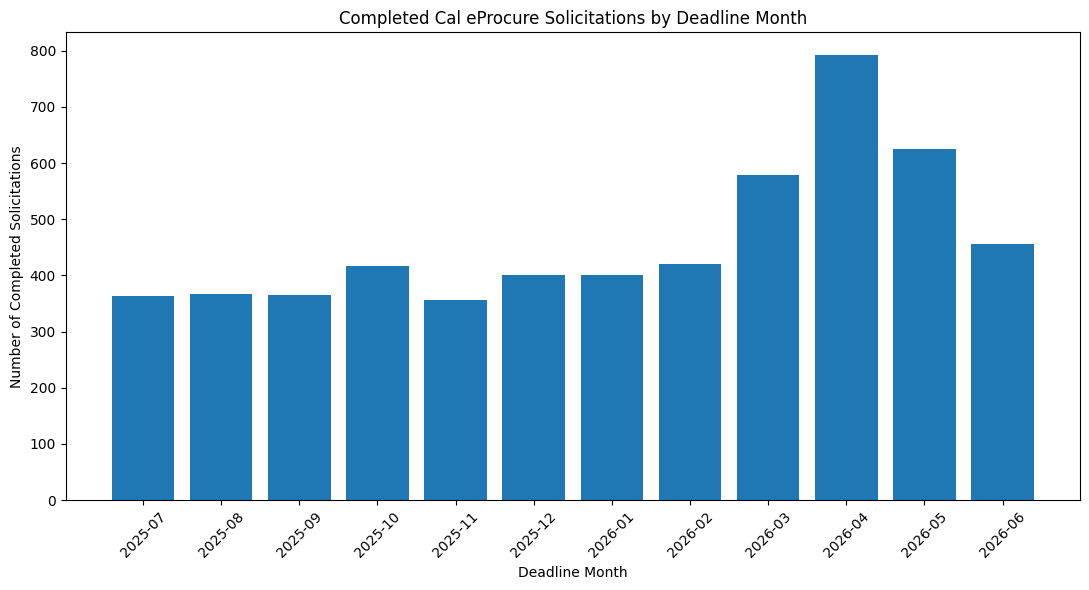

,deadline_month,solicitations
0,2025-07,364
1,2025-08,367
2,2025-09,365
3,2025-10,417
4,2025-11,357
5,2025-12,400
6,2026-01,400
7,2026-02,421
8,2026-03,578
9,2026-04,793


In [8]:
monthly_closed = (
    closed_clean.groupby("deadline_month")
    .size()
    .rename("solicitations")
    .reset_index()
)

fig, ax = plt.subplots(figsize=(11, 6))
ax.bar(monthly_closed["deadline_month"], monthly_closed["solicitations"])
ax.set_title("Completed Cal eProcure Solicitations by Deadline Month")
ax.set_xlabel("Deadline Month")
ax.set_ylabel("Number of Completed Solicitations")
ax.tick_params(axis="x", rotation=45)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "figure_1_monthly_closed_deadlines.png", dpi=150)
plt.show()

display(monthly_closed)

**Interpretation.** Figure 1 shows that the number of completed solicitations was highest in April 2026, with 793 deadlines, followed by May 2026 with 625. November 2025 had the lowest monthly count, with 357. The concentration in March through May may indicate a year-end procurement cycle, but that explanation cannot be confirmed because the data contains deadline dates rather than publication or fiscal-encumbrance dates.

## 6. Visualization 2 — Departments with the Most Completed Solicitations

This figure compares overall completed-solicitation volume by department. It reflects all procurement categories, not just technology or professional services.

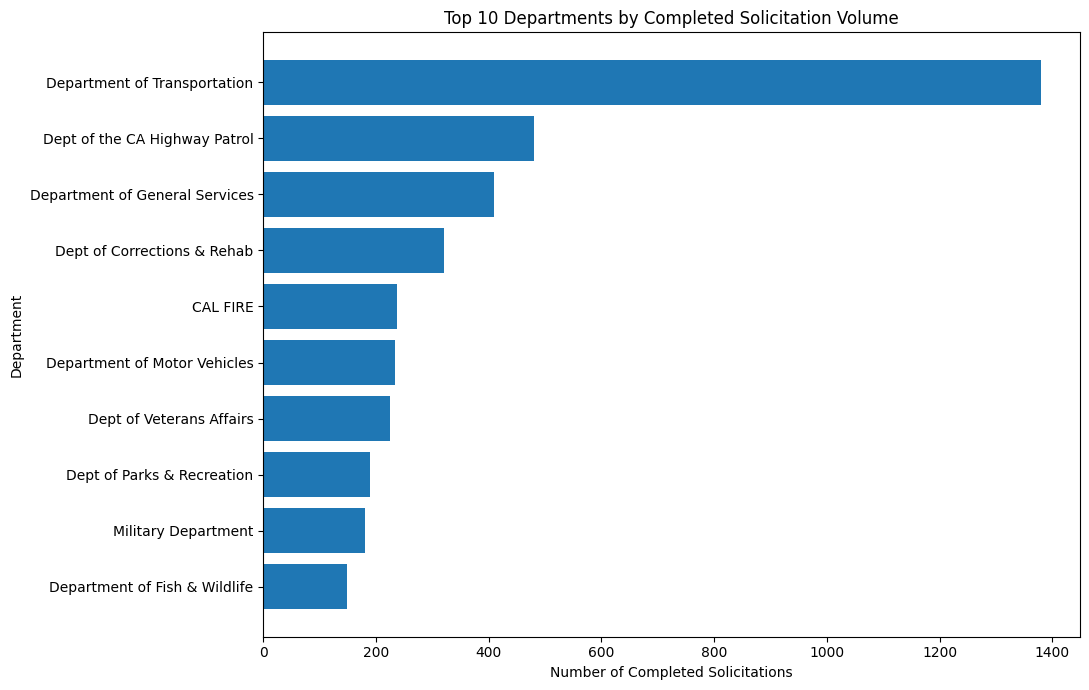

,solicitations
department_name,
Department of Transportation,1380
Dept of the CA Highway Patrol,481
Department of General Services,409
Dept of Corrections & Rehab,321
CAL FIRE,237
Department of Motor Vehicles,233
Dept of Veterans Affairs,224
Dept of Parks & Recreation,189
Military Department,181


In [9]:
top_departments = (
    closed_clean["department_name"]
    .value_counts()
    .head(10)
    .sort_values()
)

fig, ax = plt.subplots(figsize=(11, 7))
ax.barh(top_departments.index, top_departments.values)
ax.set_title("Top 10 Departments by Completed Solicitation Volume")
ax.set_xlabel("Number of Completed Solicitations")
ax.set_ylabel("Department")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "figure_2_top_departments.png", dpi=150)
plt.show()

display(top_departments.sort_values(ascending=False).rename("solicitations").to_frame())

**Interpretation.** Figure 2 shows that the Department of Transportation accounted for 1,380 of the 5,542 completed solicitations, or approximately 24.9%. The Department of the California Highway Patrol and Department of General Services were the next most active departments, with 481 and 409 solicitations. Because transportation and facilities procurements dominate the source data, statewide counts should not be treated as a direct measure of the technology-consulting market available to ICM Solutions.

## 7. Visualization 3 — Current Open Opportunities by Deadline Horizon

The deadline horizon is calculated from the July 24, 2026 data snapshot. This is a time-sensitive view and will become outdated as solicitations close or are amended.

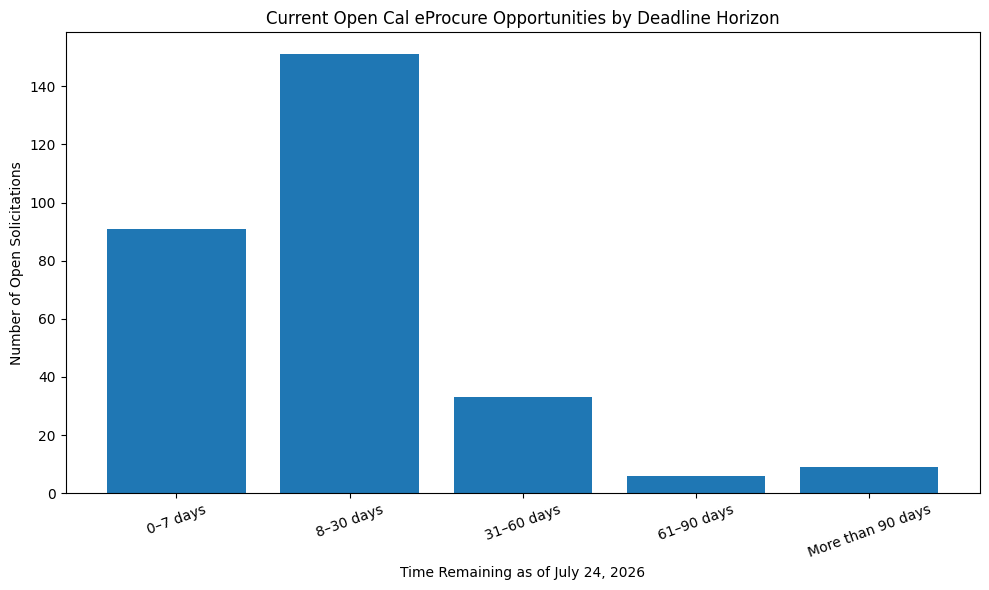

,open_solicitations
deadline_horizon,
0–7 days,91
8–30 days,151
31–60 days,33
61–90 days,6
More than 90 days,9


In [10]:
horizon_order = [
    "0–7 days",
    "8–30 days",
    "31–60 days",
    "61–90 days",
    "More than 90 days",
]

open_clean["deadline_horizon"] = pd.cut(
    open_clean["days_until_deadline"],
    bins=[-np.inf, 7, 30, 60, 90, np.inf],
    labels=horizon_order,
)

deadline_horizon_counts = (
    open_clean["deadline_horizon"]
    .value_counts(sort=False)
    .reindex(horizon_order)
)

fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(deadline_horizon_counts.index, deadline_horizon_counts.values)
ax.set_title("Current Open Cal eProcure Opportunities by Deadline Horizon")
ax.set_xlabel("Time Remaining as of July 24, 2026")
ax.set_ylabel("Number of Open Solicitations")
ax.tick_params(axis="x", rotation=20)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "figure_3_open_deadline_horizon.png", dpi=150)
plt.show()

display(deadline_horizon_counts.rename("open_solicitations").to_frame())

**Interpretation.** Figure 3 shows that 91 open solicitations were due within seven days and another 151 were due within 8–30 days. Together, 242 of 290 opportunities, or approximately 83.4%, were scheduled to close within 30 days of the snapshot. This supports a practical need for frequent monitoring, but the result does not show how long each solicitation had been open because publication dates were not included.

## 8. ICM Solutions Opportunity-Screening View

The following table applies the conservative phrase-based screening function to current event titles. It is deliberately narrow to reduce false positives from physical systems, building work, security guards, or unrelated professional services. Every result still requires manual review of the complete solicitation.

In [11]:
icm_review_candidates = (
    open_clean.loc[
        open_clean["potential_icm_alignment"],
        [
            "department_name",
            "event_id",
            "event_name",
            "end_datetime",
            "icm_alignment_categories",
            "days_until_deadline",
        ],
    ]
    .sort_values("end_datetime")
    .reset_index(drop=True)
)

print(f"Current opportunities flagged for manual ICM review: {len(icm_review_candidates)}")
display(icm_review_candidates)

Current opportunities flagged for manual ICM review: 14


,department_name,event_id,event_name,end_datetime,icm_alignment_categories,days_until_deadline
0,CA Health Benefit Exchange,0000039683,"RFP 2025-19 Microsoft 365 and Related Cloud Services Development, Administration, and Support",2026-07-27 16:00:00,"Cloud & Cybersecurity; Software, Systems & Integration",3
1,Office of Emergency Services,0000039805,Request for Information - RFI 18369 - Firefighting Resource Mobilization Platform,2026-07-29 17:00:00,"Software, Systems & Integration",5
2,"CSU, San Diego",7080,Campus Safety Systems Assessment and Strategic Planning,2026-07-31 14:00:00,"Strategy, Program & Advisory",7
3,Department of Technology,0000039869,Axway MFT Platform Cloud SaaS Subscription Renewal,2026-08-07 14:00:00,Cloud & Cybersecurity,14
4,Employment Development Dept,0000039456,EDD RFP 3475 for Salesforce M&O,2026-08-11 12:00:00,IT Operations & Application Support,18
5,Employment Development Dept,0000039854,RFQ No. 130123 Online/Virtual IT Training Courses,2026-08-12 17:00:00,IT Operations & Application Support; IT Training & Change,19
6,CA Health Benefit Exchange,0000039752,RFP 2026-04 Enterprise Strategic Planning Services,2026-08-13 16:00:00,"Strategy, Program & Advisory",20
7,Franchise Tax Board,0000039691,IFB FTB-2627-76 Genesys Software Subscriptions and Application Support Services,2026-08-17 17:00:00,IT Operations & Application Support,24
8,Statewide STPD,0000039693,CALNET Managed Cybersecurity Services IFB,2026-09-14 17:00:00,Cloud & Cybersecurity,52
9,Department of Public Health,0000037035,CDPH Centralized Application Branch (CAB) Online - RFP 26-10053,2026-10-31 12:00:00,"Software, Systems & Integration",99


## 9. Summary and Interpretation

This workflow successfully ingested 5,542 completed and 290 currently open Cal eProcure records, for a combined total of 5,832 source records. The data required limited structural cleaning, but the analysis identified 47 missing buyer-contact pairs, five Event IDs reused across departments, and several text-encoding artifacts. All deadline values were parsed successfully.

The clearest historical pattern was the concentration of completed deadlines in spring 2026, particularly April. Department-level activity was highly uneven: the Department of Transportation represented almost one-quarter of all completed records. In the current-open snapshot, more than four-fifths of opportunities were due within 30 days, showing that a periodic or automated monitoring workflow would be more useful than an infrequent manual review.

The ICM screening function identified a small set of event titles containing direct phrases related to cloud services, application support, systems integration, strategic planning, IT training, data integration, or cybersecurity. These matches are leads for human review only. Event titles do not provide enough detail to determine eligibility, contract value, staffing requirements, procurement vehicle compatibility, or probability of winning.

## 10. Assumptions, Limitations, and Bias Awareness

- The closed extract is treated as a one-year historical snapshot based on deadline dates from July 1, 2025 through June 30, 2026.
- The current-open extract is treated as accurate as of July 24, 2026. Bid amendments or status changes after that date are not reflected.
- Buyer names and emails were retained but were not used to evaluate individuals.
- Missing buyer contacts were not used as a reason to remove solicitations.
- Event ID is only unique within a broader departmental context, so a composite key is used.
- High solicitation volume does not equal high contract value, high business relevance, or greater win probability.
- Keyword screening can miss relevant opportunities that use different language and can include opportunities whose full scope is not aligned.
- The dataset lacks award amount, winning vendor, publication date, bidder count, commodity code, evaluation criteria, and full scope documents.
- Transportation and facilities solicitations dominate the data, which can distort conclusions about the narrower IT consulting market.
- The visualizations describe the supplied records; they do not establish causal explanations for procurement timing or department behavior.

## 11. Future AI Integration Reflections

### Machine-Learning Workflow Changes

A later machine-learning version would require labeled historical outcomes, such as whether ICM pursued an opportunity, passed initial qualification, submitted a proposal, reached an interview, or won. The current keyword rules could become baseline features, supplemented with solicitation text, department history, estimated effort, contract vehicle, due-date pressure, and ICM capability alignment. The data would need explicit training, validation, and test splits to prevent evaluating a model on records it already learned from.

### Neural-Network Preparation

A neural-network or transformer-based approach would require the full solicitation text rather than only short event titles. Documents would need to be collected consistently, de-duplicated, converted into machine-readable text, and labeled with reliable business outcomes. Class imbalance would also need attention because true bid opportunities and wins are likely much rarer than irrelevant or declined solicitations.

### Agentic Automation Potential

An agentic workflow could retrieve new Cal eProcure listings, apply transparent screening rules, summarize potentially relevant scopes, identify missing qualification information, and create a human-review queue. Safeguards should prevent the agent from making autonomous bid/no-bid decisions, contacting buyers, or submitting responses. Final decisions should remain with authorized ICM personnel and be supported by links to the authoritative solicitation documents.